<a href="https://colab.research.google.com/github/DJReazy/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

We use general linear/latent variable models and activation functions because they allow us to model relationships that are not strictly linear. For example, logistic regression uses a nonlinear activation (sigmoid) to map outputs into probabilities between 0 and 1. This makes them more suitable for classification problems compared to standard linear models.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy are effective because they measure how well the predicted probabilities match the true labels. They strongly penalize confident but incorrect predictions, which helps the model learn better probability estimates.

3. True or false, and explain: Logistic regression is a linear model.

True. Logistic regression is linear in the parameters because it models a linear combination of the inputs, but then applies a nonlinear function (sigmoid) to produce probabilities.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is specifically designed for classification. It predicts probabilities and then assigns classes based on a threshold.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. In logistic regression, coefficients represent the change in the log-odds, not the direct change in the predicted probability. The relationship with probability is nonlinear.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Feature engineering is still important. Logistic regression is linear in the inputs, so it cannot capture complex relationships unless we add features like interactions or polynomial terms.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is not always better than linear regression. It is better for classification problems, while linear regression is better for predicting continuous values. The choice depends on the problem.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [3]:
import pandas as pd

# Load with correct delimiter
df = pd.read_csv("data.csv", sep=";")

# Keep relevant columns
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]

# Drop missing values (simple approach)
df = df.dropna()

# Create binary target: 1 = Dropout, 0 = Not dropout
df["Dropout"] = (df["Target"] == "Dropout").astype(int)

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [4]:
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["Dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


# 2.2
The coefficients show how each variable affects dropout.

Being a debtor (0.53) and having a higher age at enrollment (0.05) both increase the chance of dropping out.

Being up to date on tuition (-2.56) greatly reduces the chance of dropping out, and being a scholarship holder (-1.23) also lowers the risk.

Overall, being up to date on tuition has the strongest effect and clearly reduces dropout probability.

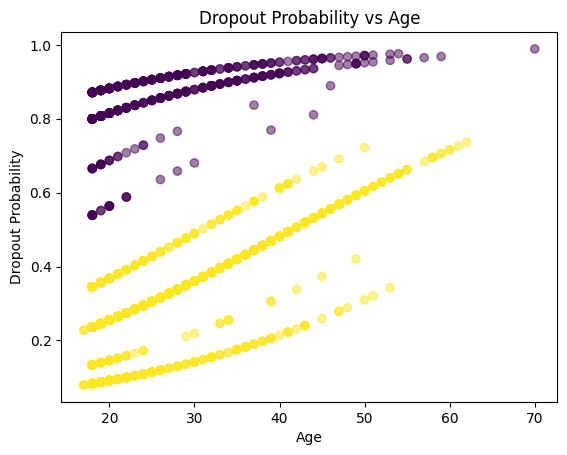

In [5]:
import matplotlib.pyplot as plt

df["dropout_prob"] = model.predict_proba(X)[:, 1]

plt.scatter(
    df["Age at enrollment"],
    df["dropout_prob"],
    c=df["Tuition fees up to date"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Dropout Probability")
plt.title("Dropout Probability vs Age")
plt.show()

# 2.3

From the plot, dropout probability increases with age for all students.

Students who are not up to date on tuition (dark points) consistently have much higher dropout probabilities across all ages. Students who are up to date (light points) have significantly lower probabilities.

The gap between the two groups is fairly consistent, but it is most noticeable in the mid-age range (around 25–45) where the separation is very clear.

On average, being up to date on tuition reduces dropout probability by a large margin (roughly 0.3–0.5 depending on age).

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 0.7619801084990958
Confusion Matrix:
 [[2841  162]
 [ 891  530]]


# 2.4

The model achieves an accuracy of about 76.2%, which indicates reasonably good performance.

From the confusion matrix:

The model correctly identifies many non-dropouts (2841 correct vs 162 incorrect).
However, it struggles more with dropouts, misclassifying a large number of them (891 missed vs 530 correctly identified).

This means the model is better at predicting students who will not drop out than those who will. It has a relatively high number of false negatives (actual dropouts predicted as non-dropouts), which is important since those are the students we most want to identify.

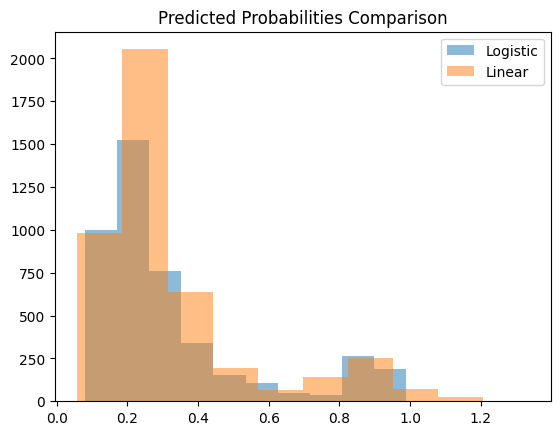

In [7]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)

plt.hist(df["dropout_prob"], alpha=0.5, label="Logistic")
plt.hist(lin_probs, alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

# 2.5

The logistic regression model produces probabilities that are bounded between 0 and 1, which makes them valid and interpretable as true probabilities.
The linear model, however, produces some values outside the [0, 1] range (e.g., above 1), which are not meaningful as probabilities.
From the histogram:


Logistic predictions are more well-structured and concentrated, especially near realistic probability ranges.


Linear predictions are more spread out and less reliable, especially at higher values.


Overall, logistic regression performs better for this task because it naturally models probabilities and avoids invalid predictions.

# 2.6

Students most at risk are those with outstanding debt and those not up to date on tuition. Older students may also show different risk patterns. Interventions could include financial support, payment plans, and academic advising.

In [8]:
multi_X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

multi_y = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(multi_X, multi_y)

pred = multi_model.predict(multi_X)

print(confusion_matrix(multi_y, pred))

probs = multi_model.predict_proba(multi_X)
print(probs[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# 2.7

From the confusion matrix, the model is only predicting two classes and completely fails to predict one class (the middle column is all zeros). This means the hard classification using .predict() is not capturing all categories, likely ignoring the “Graduate” class.

From the predicted probabilities (predict_proba), we see that the model does assign probabilities to all three classes. For example:

Some rows have high probability for class 1 or 2, even though they are never chosen in the final prediction.
The probabilities are more nuanced and show the model is considering all classes.

Conclusion:

The hard classification does not predict every class, which is a limitation.
The probability outputs do include all classes, so they provide a better picture of the model’s understanding.
This suggests the model is biased toward certain classes when making final predictions, even though it internally considers all options.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [10]:
# Q3 - Cirrhosis survival analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# -----------------------------
# 1. Load and clean data
# -----------------------------
df = pd.read_csv("cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols].dropna()

# Binary target for survival:
# 1 = alive (C or CL), 0 = dead (D)
df["Survival"] = df["Status"].isin(["C", "CL"]).astype(int)

# Encode categorical predictors
# Edema: N, S, Y
# Drug: D-penicillamine vs placebo
df["Drug_bin"] = (df["Drug"] == "D-penicillamine").astype(int)

edema_dummies = pd.get_dummies(df["Edema"], prefix="Edema", drop_first=True)

# Final dataframe for binary survival model
df_model = pd.concat(
    [df[["Bilirubin", "Drug_bin", "Survival", "Stage"]], edema_dummies],
    axis=1
)

print(df_model.head())
print(df_model.shape)

   Bilirubin  Drug_bin  Survival  Stage  Edema_S  Edema_Y
0       14.5         1         0    4.0    False     True
1        1.1         1         1    3.0    False    False
2        1.4         1         0    4.0     True    False
3        1.8         1         0    4.0     True    False
4        3.4         0         1    3.0    False    False
(312, 6)


In [11]:
# -----------------------------
# 2. Logistic regression of Survival on Edema, Drug, Bilirubin
# -----------------------------
X = df_model.drop(columns=["Survival", "Stage"])
y = df_model["Survival"]

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X, y)

coeffs = pd.Series(log_model.coef_[0], index=X.columns)
print("Logistic coefficients:")
print(coeffs)
print("Intercept:", log_model.intercept_[0])

Logistic coefficients:
Bilirubin   -0.351450
Drug_bin    -0.231952
Edema_S     -0.451483
Edema_Y     -1.613160
dtype: float64
Intercept: 1.6116486564631036


# 3.2

From the logistic regression results:


Bilirubin (-0.351): Higher bilirubin is associated with a lower survival probability, which makes sense since it reflects worse liver function.


Drug (-0.232): The negative coefficient suggests that the drug is associated with a slightly lower survival probability, meaning it does not appear to improve survival in this model.


Edema_S (-0.451) and Edema_Y (-1.613): Both are negative, and Edema_Y has a much stronger negative effect, indicating that more severe edema is linked to significantly lower survival probability.


Overall, higher bilirubin and more severe edema strongly reduce survival, and the drug does not show a positive effect on survival in this dataset.

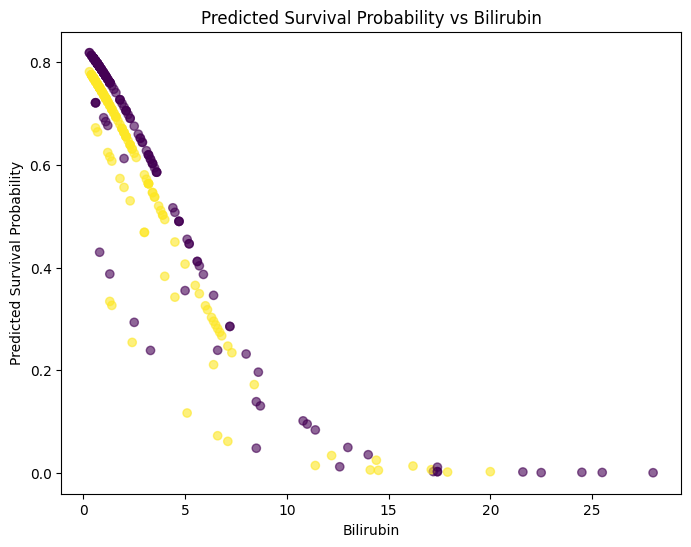

Average predicted survival by drug group:
Drug_bin
0    0.608971
1    0.589990
Name: survival_prob, dtype: float64
Average difference (drug - placebo): -0.018980879606600665


In [12]:
# -----------------------------
# 3. Predicted survival probabilities + scatter plot
# -----------------------------
df_model["survival_prob"] = log_model.predict_proba(X)[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df_model["Bilirubin"],
    df_model["survival_prob"],
    c=df_model["Drug_bin"],
    alpha=0.6
)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

# Average effect of drug on predicted survival probability
avg_survival_by_drug = df_model.groupby("Drug_bin")["survival_prob"].mean()
print("Average predicted survival by drug group:")
print(avg_survival_by_drug)
print("Average difference (drug - placebo):", avg_survival_by_drug.loc[1] - avg_survival_by_drug.loc[0])

# 3.3

From the plot, survival probability decreases sharply as bilirubin increases, showing that higher bilirubin is strongly associated with worse outcomes.

Comparing the two groups:

Patients on the drug do not show higher survival probabilities than those on placebo.
In fact, the drug group is slightly lower across most bilirubin values.

The effect of the drug does not vary much across bilirubin levels—the curves are fairly parallel, meaning the drug does not improve survival at any specific range.

On average, the drug reduces survival probability slightly (about 0.02), indicating no meaningful benefit in this dataset.

In [13]:
# -----------------------------
# 4. Confusion matrix and accuracy
# -----------------------------
y_pred = log_model.predict(X)

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.7371794871794872
Confusion Matrix:
[[ 59  66]
 [ 16 171]]


# 3.4

The model achieves an accuracy of about 73.7%, indicating moderate performance.

From the confusion matrix:

The model correctly predicts many survivors (171 correct vs 16 missed).
However, it struggles more with non-survivors, misclassifying a large number of them (66 incorrect vs 59 correct).

This means the model is better at predicting survival than death, with a relatively high number of false positives (predicting survival when the patient does not survive).

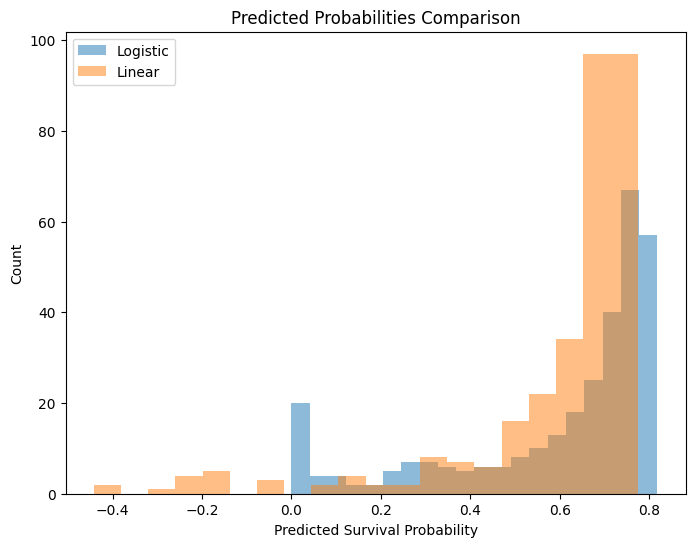

Linear prediction range: -0.441739668393599 0.7738680250928711
Logistic prediction range: 0.0001698505017129852 0.8184994117437242


In [14]:
# -----------------------------
# 5. Linear model comparison
# -----------------------------
lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)

plt.figure(figsize=(8, 6))
plt.hist(df_model["survival_prob"], bins=20, alpha=0.5, label="Logistic")
plt.hist(lin_probs, bins=20, alpha=0.5, label="Linear")
plt.xlabel("Predicted Survival Probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities Comparison")
plt.legend()
plt.show()

print("Linear prediction range:", lin_probs.min(), lin_probs.max())
print("Logistic prediction range:", df_model["survival_prob"].min(), df_model["survival_prob"].max())

# 3.5

The logistic regression model produces probabilities strictly between 0 and 1 (about 0.0002 to 0.82), which makes them valid and interpretable.

The linear model, however, produces values outside the [0,1] range (as low as -0.44), which are not meaningful as probabilities.

From the histogram:

Logistic predictions are more concentrated and realistic
Linear predictions are more spread out and less reliable

Overall, logistic regression performs better for this task because it produces valid probabilities and more meaningful predictions.

In [15]:
# -----------------------------
# 6. Logistic regression of Stage on Edema and Bilirubin
# -----------------------------
# Build features for multinomial model
X_stage = df_model.drop(columns=["Survival", "Stage", "Drug_bin"])
y_stage = df_model["Stage"]

stage_model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000
)
stage_model.fit(X_stage, y_stage)

stage_pred = stage_model.predict(X_stage)
stage_cm = confusion_matrix(y_stage, stage_pred)

print("Stage confusion matrix:")
print(stage_cm)

stage_probs = stage_model.predict_proba(X_stage)
print("First 5 predicted probability rows:")
print(stage_probs[:5])

print("Classes:", stage_model.classes_)
print("Predicted classes present:", np.unique(stage_pred))

Stage confusion matrix:
[[ 0  0 15  1]
 [ 0  0 61  6]
 [ 0  0 97 23]
 [ 0  0 64 45]]
First 5 predicted probability rows:
[[1.49045561e-05 4.36585649e-02 1.60124147e-01 7.96202383e-01]
 [7.28203187e-02 2.52994626e-01 4.05800192e-01 2.68384864e-01]
 [2.97319782e-02 1.75083065e-01 3.95826931e-01 3.99358026e-01]
 [2.35888738e-02 1.67637129e-01 3.91591026e-01 4.17182972e-01]
 [2.04525649e-02 2.25909021e-01 4.21426039e-01 3.32212375e-01]]
Classes: [1. 2. 3. 4.]
Predicted classes present: [3. 4.]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# 3.6

From the confusion matrix, the model only predicts Stages 3 and 4, and completely fails to predict Stages 1 and 2. This means the hard classification using .predict() is not capturing all classes and is biased toward later disease stages.

However, the .predict_proba() results show that the model does assign probabilities to all four stages. For example, in the first few rows, each stage has a nonzero probability, even if it is not selected as the final prediction.

Conclusion:

The hard classification does not predict every class, which is a limitation of the model.
The predicted probabilities do include all classes, giving a more complete picture.
This suggests the model is biased toward predicting more severe stages, even though it internally considers all possibilities.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

## Q4

### 1. Linear model

For the linear model,

$\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$

the derivative with respect to the $k$-th feature is

$\frac{\partial \hat{y}}{\partial x_k} = b_k$

So for a 1-unit increase in $x_k$, the prediction changes by

$\Delta \hat{y} = b_k$

This is constant and does not depend on $x$.

---

### 2. Logistic model

For logistic regression,

$\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}$

Let $L = b \cdot x$. Then

$\hat{p} = \frac{e^L}{1 + e^L}$

Using the chain rule:

$\frac{\partial \hat{p}}{\partial x_k} = \frac{d\hat{p}}{dL} \cdot \frac{\partial L}{\partial x_k}$

We have:

$\frac{d\hat{p}}{dL} = \hat{p}(1 - \hat{p})$

and

$\frac{\partial L}{\partial x_k} = b_k$

So,

$\frac{\partial \hat{p}}{\partial x_k} = b_k \hat{p}(1 - \hat{p})$

This means the effect of $x_k$ is not constant and depends on $\hat{p}$.

The term $\hat{p}(1 - \hat{p})$ is largest when $\hat{p} = 0.5$, where it equals $0.25$.

So near $\hat{p} = 0.5$:

$\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}$

---

### 3. Log-odds interpretation

We can rewrite the model as:

$\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x$

Taking the derivative:

$\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b_k$

So a 1-unit increase in $x_k$ changes the **log-odds** by $b_k$.

---

### Final interpretation

- In a linear model, $b_k$ is the direct change in prediction.
- In logistic regression, $b_k$ is the change in log-odds.
- The change in probability is $b_k \hat{p}(1 - \hat{p})$, so it depends on $\hat{p}$.